In [50]:
import sys
import os
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '../')

from FL_code.prior_calculator import PriorCalculator
from FL_code.cancer_quantizer import WZQuantizerCancer
from FL_code.run_fl import FLConfig
from FL_code.models import initialize_model
from FL_code.utils import StateDictManager
from FL_code.cancer_protocol import CancerConfig


data_dir = '../data/training_grads'
all_x_data = [torch.load(os.path.join(data_dir, f)) for f in os.listdir(data_dir) if f.endswith('.pt')]
all_x_data = torch.concat(all_x_data, dim=0)

sdm = StateDictManager(initialize_model(FLConfig(), torch.device(f"cuda")))
vec_slices = []
offset = 0
for temp in sdm.numels:
    vec_slices.append(slice(offset, offset + temp))
    offset += temp
for temp in sdm.numels:
    vec_slices.append(slice(offset, offset + temp))
    offset += temp

In [51]:
num_planes, bins_per_plane = 3, 8
outlier_threshold = 1.5

quantizer = WZQuantizerCancer(
    CancerConfig(), FLConfig(),
    num_planes, bins_per_plane, si_size=0, norm_slices=vec_slices, outlier_threshold = 1.5)

quantizer.coding_model.load_state_dict(
    torch.load('../data/pre_trained_pth/bpp8_np3_pretrained_wzq_rnn.pth'))

quantizer.train_model(all_x_data, None)

In [52]:
x_prep, prep_param = quantizer.get_x_data(all_x_data)
x_prep_revert = quantizer._post_process(x_prep, *prep_param).cpu().numpy()
x_prep = x_prep.squeeze().cpu().numpy()

In [53]:
# idx = torch.randperm(x_prep.shape[0])[:500_000]
# plt.scatter(all_x_data[idx], x_prep_revert[idx])
# # plt.scatter(all_x_data[idx], x_prep[idx], alpha=0.1)
# plt.title('Preprocessed vs original gradient values')
# plt.xlabel('Original gradient value')
# plt.ylabel('Preprocessed gradient value (reverted)')
# plt.show()

In [54]:
payload = quantizer.encoding_process(all_x_data)
recons = quantizer.decoding_process(payload)

temp = quantizer._get_posterior(all_x_data, payload[0])
rate = PriorCalculator.compute_rate_from_prior_tensor(
    temp, payload[0], num_planes)
rate

3.9072265625

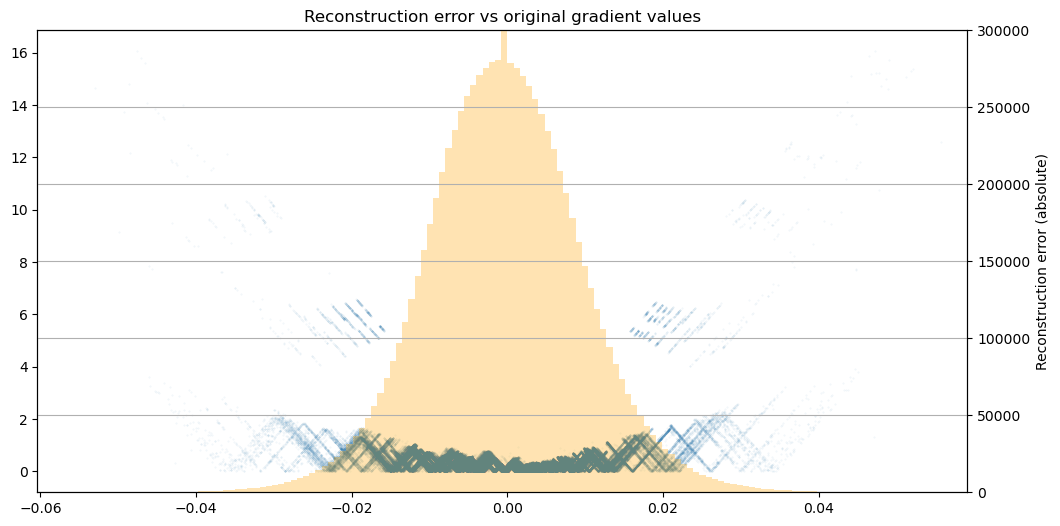

In [55]:
plt.figure(figsize=(12, 6))
idx = torch.randperm(recons.shape[0])[:500_000]
x = all_x_data[idx]
y = (torch.abs(all_x_data[idx] - recons[idx])/torch.abs(x).mean())
plt.scatter(x, y, alpha=0.1, s=0.1)
# plt.ylim(-0.1, 7)

second_plot = plt.twinx()
second_plot.hist(all_x_data, bins=200, color='orange', alpha=0.3)
second_plot.set_ylim([-0.1, 3e5])
second_plot.set_xlim([torch.min(x), torch.max(x)])

plt.title('Reconstruction error vs original gradient values')
plt.xlabel('Original gradient value')
plt.ylabel('Reconstruction error (absolute)')
plt.grid()
plt.show()

In [56]:
# temp = f'bpp{bins_per_plane}_np{num_planes}_pretrained_wzq_rnn'
# torch.save(quantizer.coding_model.state_dict(), f'../data/pre_trained_pth/{temp}.pth')